# Import

In [1]:
import pandas as pd
from pathlib import Path
from phenoseeker import EmbeddingManager


# Load data

In [2]:
metadata_path = Path('/home/maxime/data/jump_embeddings/dinov2_g/compounds/metadata.parquet')
embeddings_path = Path('/home/maxime/data/jump_embeddings/dinov2_g/compounds/Embeddings_norm.npy')

In [3]:
metadata_path_syn0105 = Path('/home/maxime/synrepos/phenospace/features_extractor/features/SYN-0105/metadata.csv')
embeddings_path_syn0105 = Path('/home/maxime/synrepos/phenospace/features_extractor/features/SYN-0105/extracted_features.npy')

In [4]:
jump_em = EmbeddingManager(metadata_path, entity="compound")
jump_em.load("Embeddings_norm", embeddings_path)



In [5]:
img_em_syn0105 = EmbeddingManager(metadata_path_syn0105, entity="image")
img_em_syn0105.load("Embeddings_Raw", embeddings_path_syn0105)

In [6]:
plate_map_df = pd.read_csv('/home/maxime/synrepos/phenospace/features_extractor/notebooks/plamemap_SYN-0105.csv')

In [7]:
def find_dsmo(id):
    if id == 'IKT-DMSO':
        return "InChI=1S/C2H6OS/c1-4(2)3/h1-2H3"
    else:
        return id

In [8]:
img_em_syn0105.df = img_em_syn0105.df.merge(plate_map_df, on=['Metadata_Row', 'Metadata_Column'])
img_em_syn0105.df['Metadata_Col'] = img_em_syn0105.df['Metadata_Column']
img_em_syn0105.df['Metadata_InChI'] = img_em_syn0105.df['Metadata_Molecule_ID'].apply(find_dsmo)


In [9]:
well_em_syn0105 = img_em_syn0105.grouped_embeddings(group_by='well', embeddings_name="Embeddings_Raw", new_embeddings_name='Embeddings_Raw', cols_to_keep=['Metadata_Batch', 'Metadata_Molecule_ID', 'Metadata_InChI'])

100%|██████████| 384/384 [00:00<00:00, 456.65it/s]


In [10]:
well_em_syn0105

Embedding Manager with 384 wells embeddings

In [11]:
well_em_syn0105.apply_spherizing_transform('Embeddings_Raw', 'Embeddings__ZCA_C', method='ZCA', norm_embeddings=False, use_control=True, n_jobs=1)
well_em_syn0105.apply_inverse_normal_transform('Embeddings_Raw', 'Embeddings__ZCA_C__Int')

Applying INT by plate: 100%|██████████| 1/1 [00:00<00:00, 1100.00it/s]


In [12]:
compounds_em_syn_0105 = well_em_syn0105.grouped_embeddings(group_by='compound', embeddings_name="Embeddings__ZCA_C__Int", cols_to_keep=['Metadata_Molecule_ID', 'Metadata_InChI',	"Metadata_Is_dmso"])

100%|██████████| 21/21 [00:00<00:00, 14496.44it/s]


In [13]:
compounds_em_syn_0105_raw = well_em_syn0105.grouped_embeddings(group_by='compound', embeddings_name="Embeddings_Raw")

100%|██████████| 21/21 [00:00<00:00, 16844.59it/s]


In [14]:
compounds_em_syn_0105.embeddings['Embeddings_Raw'] = compounds_em_syn_0105_raw.embeddings['Embeddings_mean']

# Separate Analysis

## SYN-0105

Matrix 'cosine_similarity_matrix_Embeddings_mean' not found. Computing it now...


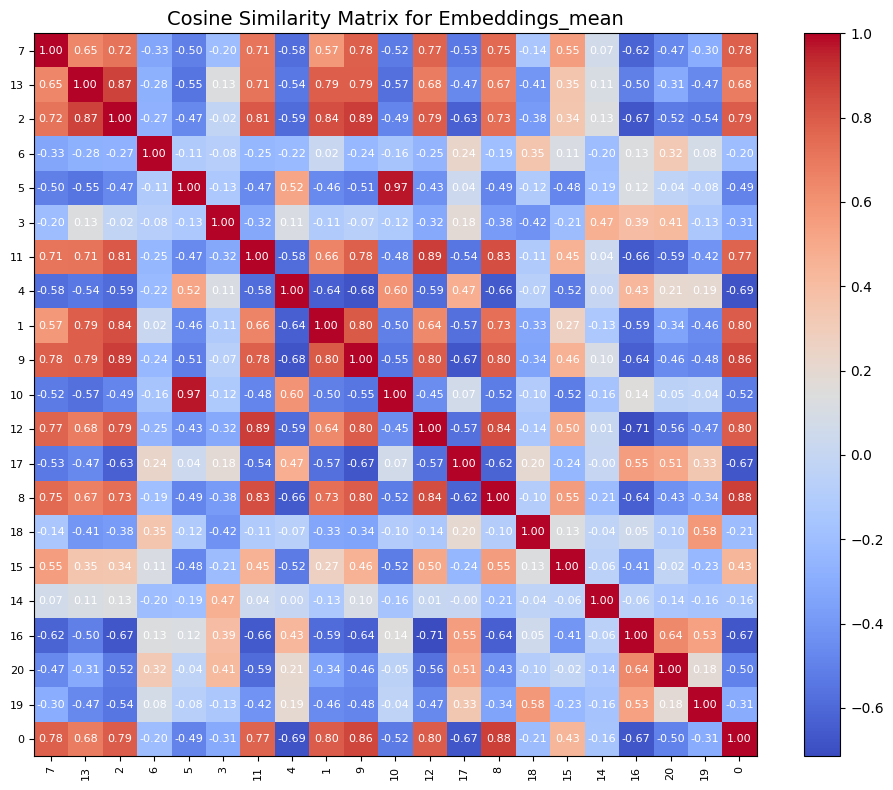

In [15]:
compounds_em_syn_0105.plot_distance_matrix("Embeddings_mean", distance='cosine', sort_by='Metadata_Molecule_ID', similarity=True)

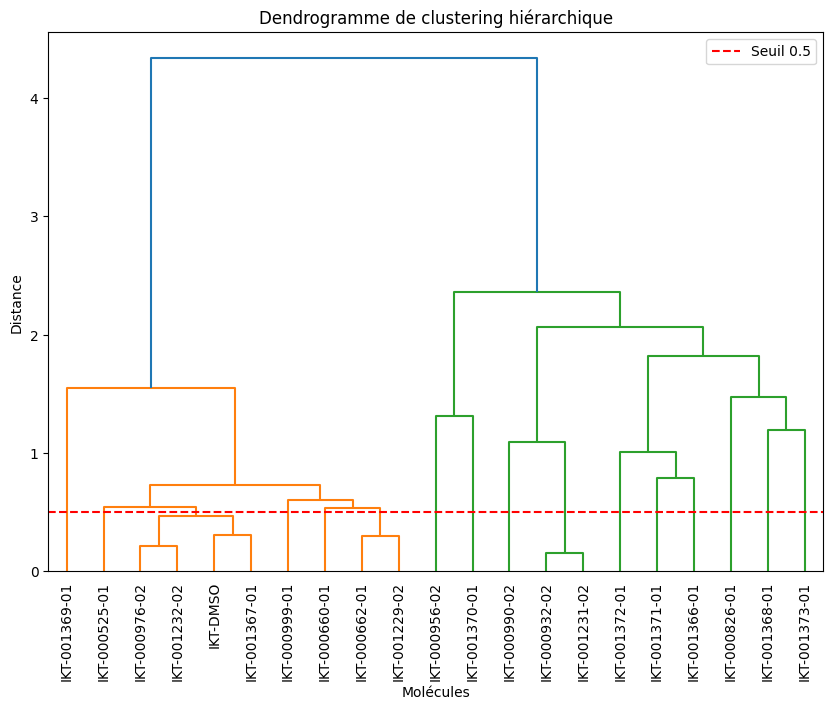

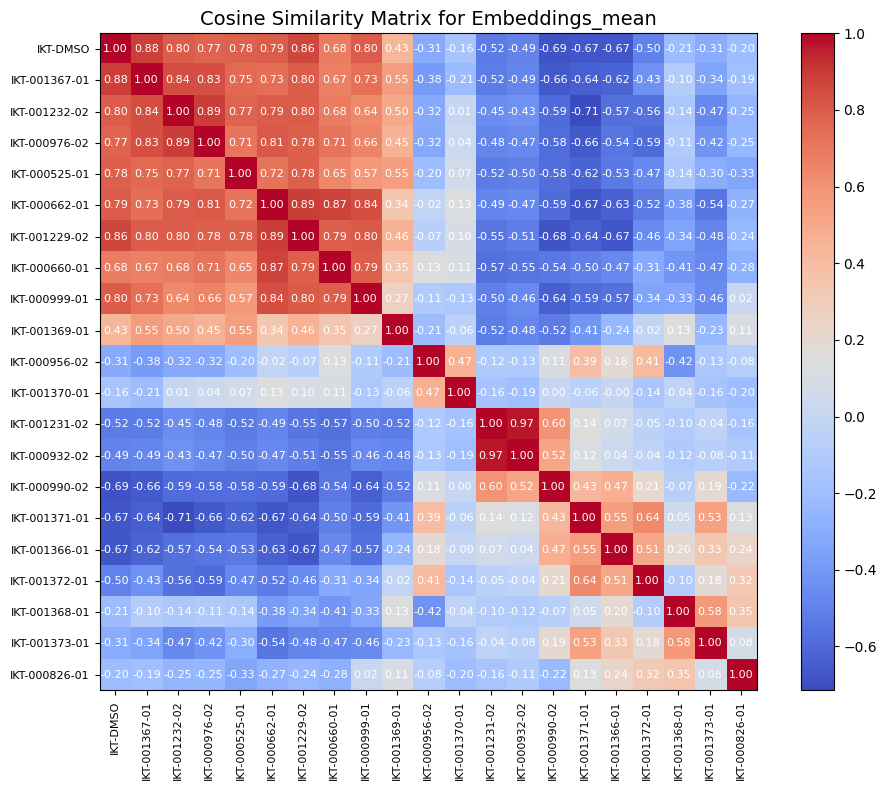

In [16]:
compounds_em_syn_0105.hierarchical_clustering_and_visualization('Embeddings_mean')
compounds_em_syn_0105.plot_distance_matrix("Embeddings_mean", distance='cosine', sort_by='Cluster', label_by='Metadata_Molecule_ID', similarity=True)

In [75]:
compounds_em_syn_0105.df['Metadata_Controls'] = compounds_em_syn_0105.df['Metadata_Molecule_ID'].apply(assign_ctrls)

In [76]:
ctrl_syn0105_em = compounds_em_syn_0105.filter_and_instantiate(Metadata_Controls=["ctrl -", 'ctrl +'])

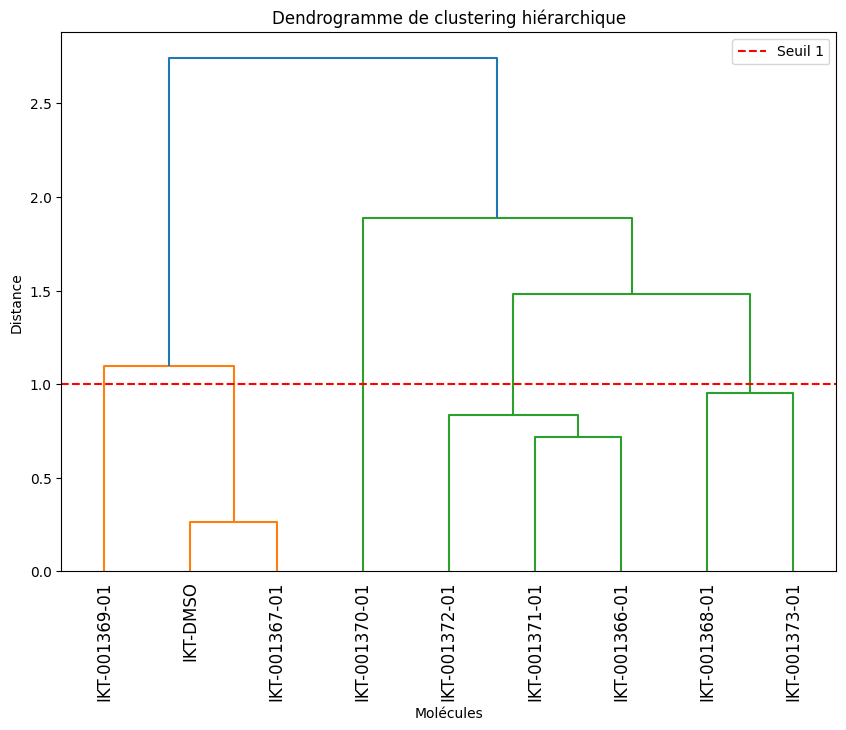

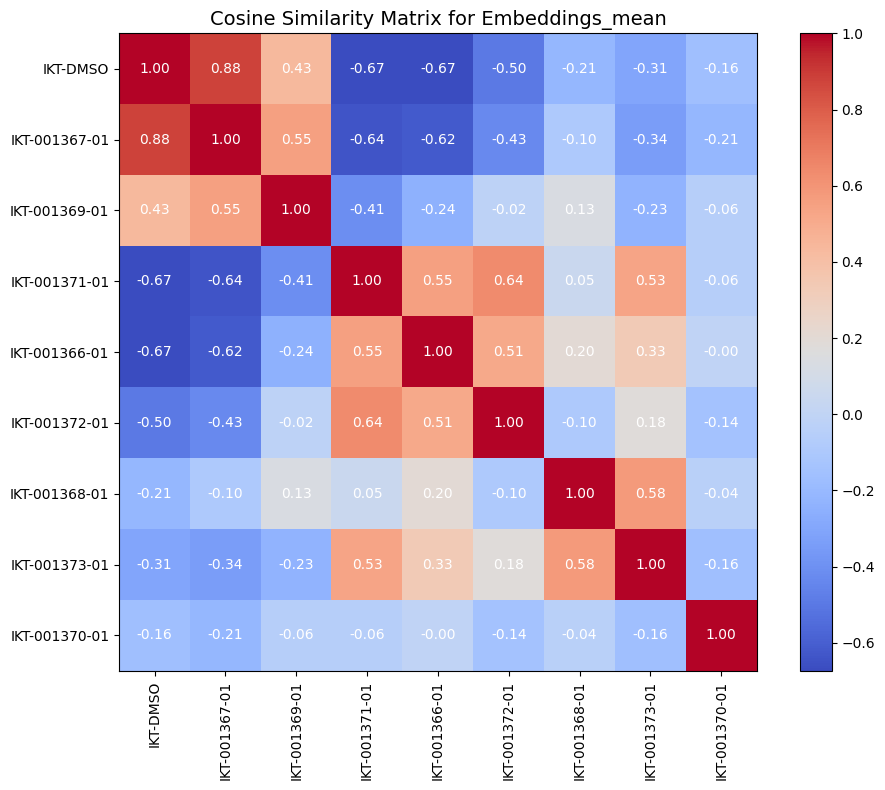

In [78]:
ctrl_syn0105_em.hierarchical_clustering_and_visualization('Embeddings_mean', threshold=1)
ctrl_syn0105_em.plot_distance_matrix("Embeddings_mean", distance='cosine', sort_by='Cluster', label_by='Metadata_Molecule_ID', similarity=True, fontsize=10)

## JUMP ctrls

In [17]:
jump_ctrl = jump_em.filter_and_instantiate(Metadata_JCP2022=jump_em.JCP_ID_controls)

In [23]:
jump_ctrl.JCP_ID_poscon

['JCP2022_085227',
 'JCP2022_037716',
 'JCP2022_025848',
 'JCP2022_046054',
 'JCP2022_035095',
 'JCP2022_064022',
 'JCP2022_050797',
 'JCP2022_012818']

In [22]:
jump_ctrl.JCP_ID_controls

['JCP2022_085227',
 'JCP2022_037716',
 'JCP2022_025848',
 'JCP2022_046054',
 'JCP2022_035095',
 'JCP2022_064022',
 'JCP2022_050797',
 'JCP2022_012818',
 'JCP2022_033924']

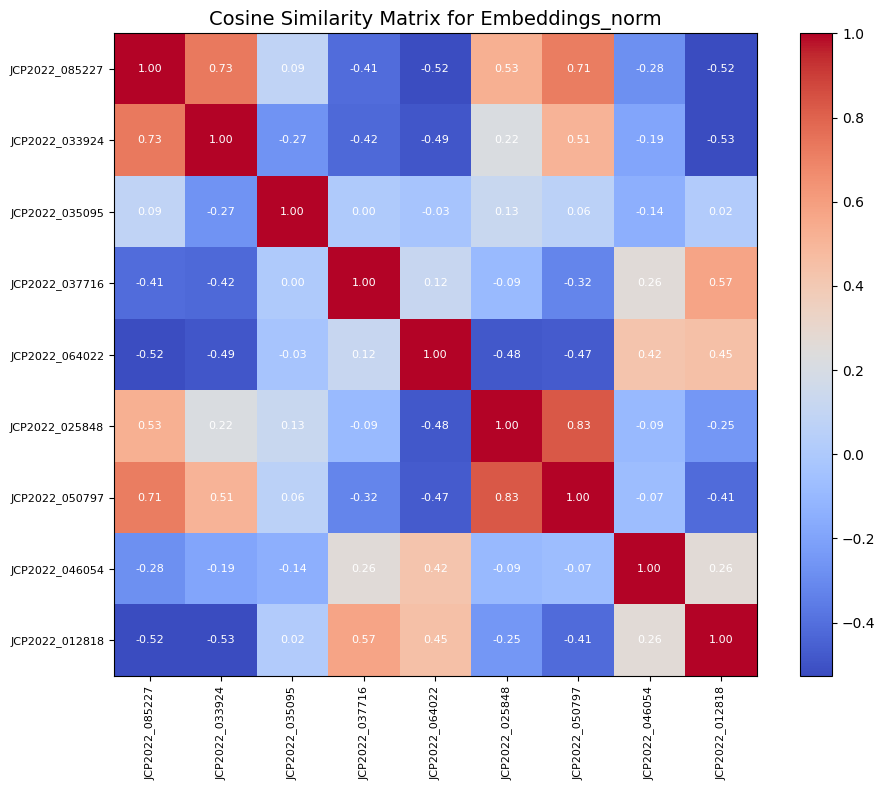

In [21]:
jump_ctrl.plot_distance_matrix('Embeddings_norm', similarity=True, label_by="Metadata_JCP2022")

# Check controls

In [29]:
jump_ctrl_df = jump_ctrl.df[['Metadata_JCP2022']]

In [31]:
jump_ctrl_df.columns = ["Metadata_Molecule_ID"]

In [36]:
import numpy as np

# Assuming embeddings are numpy arrays
combined_embeddings = np.concatenate((jump_ctrl.embeddings['Embeddings_norm'], compounds_em_syn_0105.embeddings['Embeddings_mean']), axis=0)


In [38]:
combined_embeddings.shape

(30, 1536)

In [40]:
df_combined = pd.concat([jump_ctrl_df, compounds_em_syn_0105.df[['Metadata_Molecule_ID']]]).reset_index(drop=True)

In [41]:
combined_em = EmbeddingManager(df_combined, 'compound')

In [42]:
combined_em.embeddings['Embeddings_norm'] = combined_embeddings

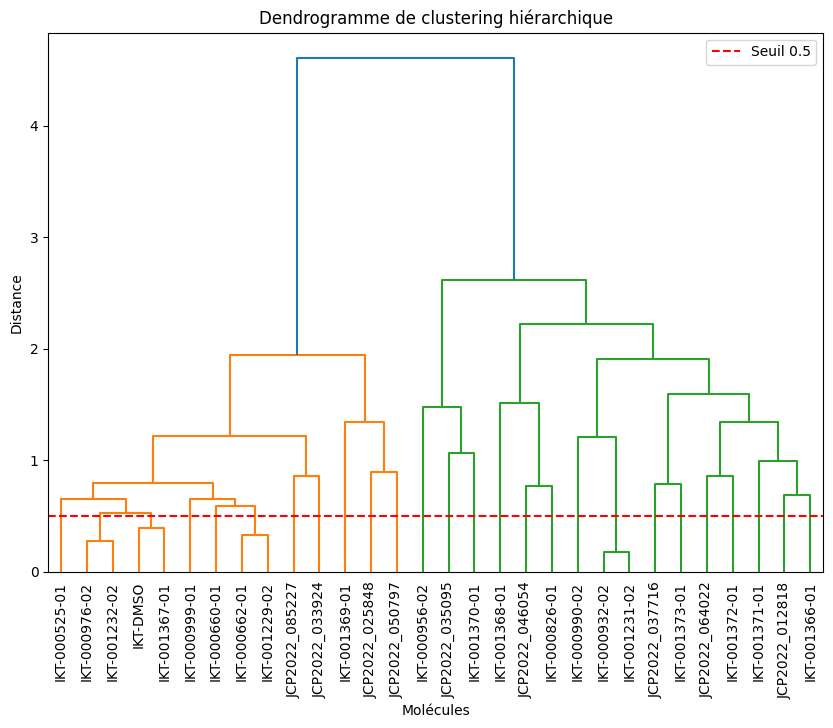

In [47]:
combined_em.hierarchical_clustering_and_visualization('Embeddings_norm')

In [50]:
combined_em.df

,Metadata_Molecule_ID,Cluster
0,JCP2022_085227,7
1,JCP2022_033924,8
2,JCP2022_035095,12
3,JCP2022_037716,20
4,JCP2022_064022,22
5,JCP2022_025848,9
6,JCP2022_050797,10
7,JCP2022_046054,15
8,JCP2022_012818,24
9,IKT-DMSO,2


In [53]:
def assign_ctrls(ikt_id):
    if ikt_id in ["IKT-001367-01",
"IKT-001370-01",
"IKT-001369-01",
"IKT-001371-01",
"IKT-001366-01",
"IKT-001368-01",
"IKT-001373-01",
"IKT-001372-01"]:
        return "ctrl +"
    elif ikt_id =='IKT-DMSO':
        return "ctrl -"
    elif ikt_id in jump_ctrl.JCP_ID_poscon:
        return "ctrl +"
    elif ikt_id == 'JCP2022_033924':
        return "ctrl -"
    else:
        return "sample"    

In [54]:
combined_em.df['Metadata_Controls'] = combined_em.df['Metadata_Molecule_ID'].apply(assign_ctrls)

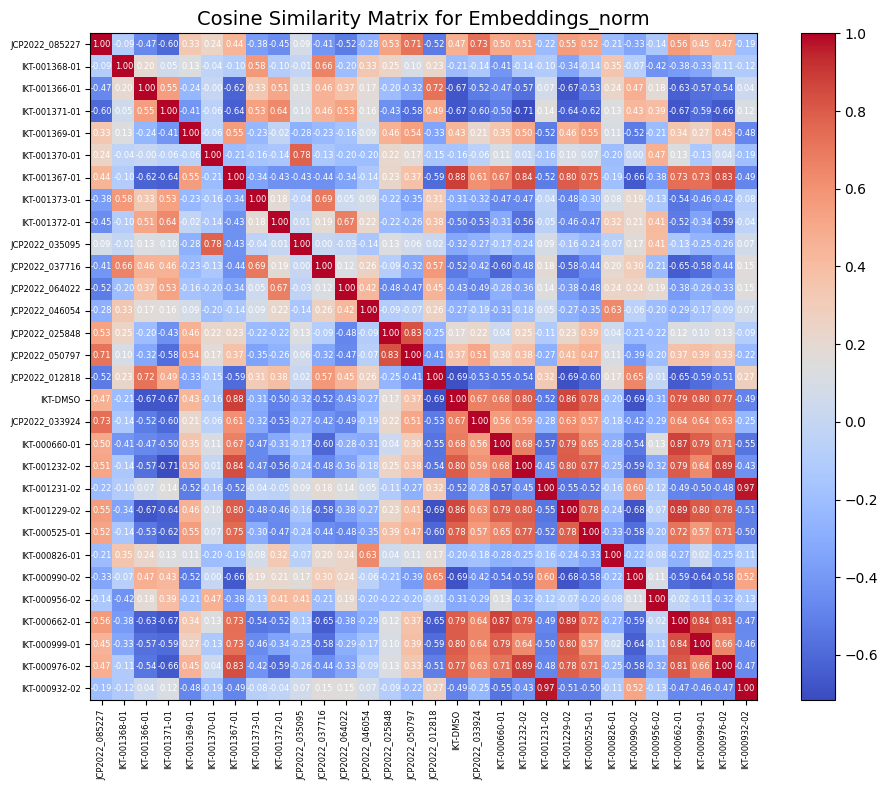

In [55]:
combined_em.plot_distance_matrix('Embeddings_norm', similarity=True, sort_by='Metadata_Controls', label_by="Metadata_Molecule_ID", fontsize=6)

In [67]:
ctrl_combined_em = combined_em.filter_and_instantiate(Metadata_Controls=['ctrl +', 'ctrl -'])

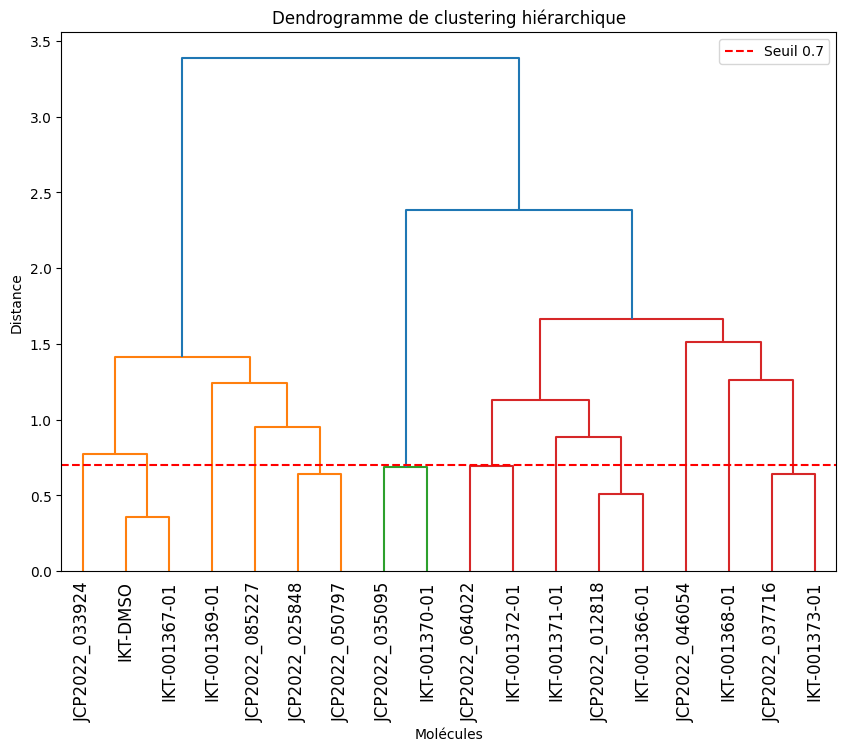

In [73]:
ctrl_combined_em.hierarchical_clustering_and_visualization('Embeddings_norm', threshold=0.7)

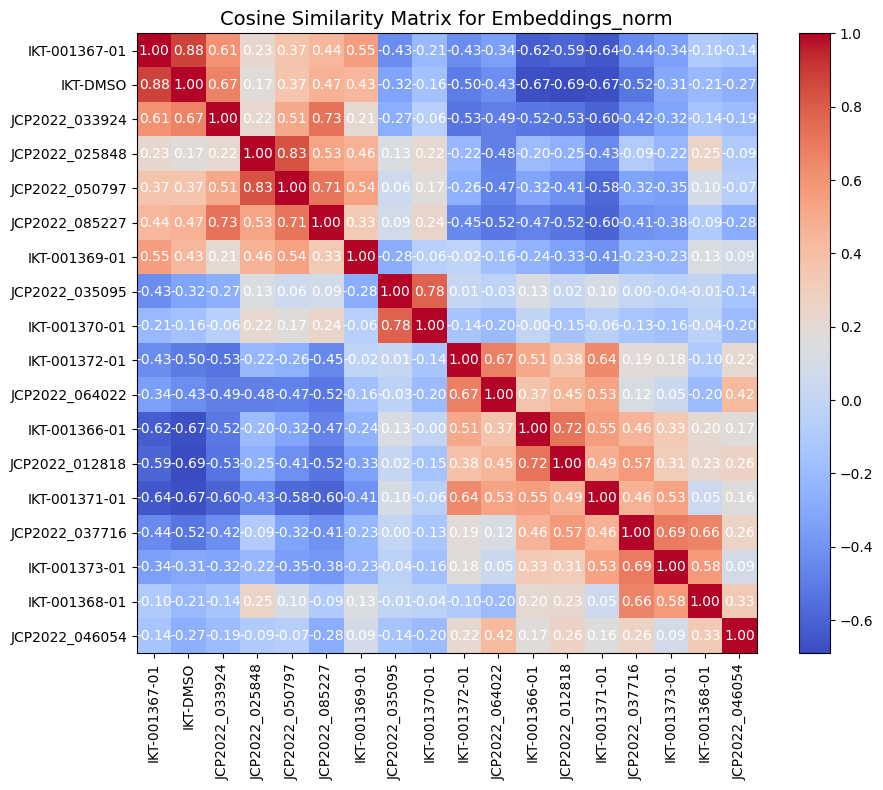

In [74]:
ctrl_combined_em.plot_distance_matrix('Embeddings_norm', similarity=True, sort_by='Cluster', label_by="Metadata_Molecule_ID", fontsize=10)

In [63]:
dmso_combined_em = combined_em.filter_and_instantiate(Metadata_Controls='ctrl -')

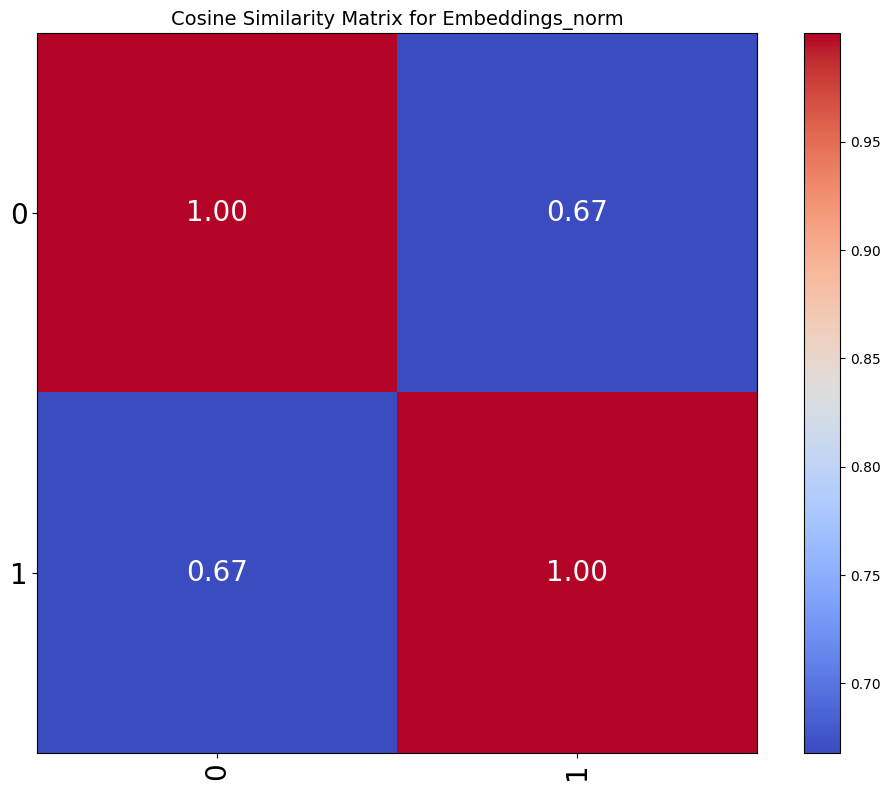

In [66]:
dmso_combined_em.plot_distance_matrix('Embeddings_norm', similarity=True, fontsize=20)